In [149]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle

In [150]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp100 = market.retrieve("sp100")
market.disconnect()

In [151]:
training_year = 2020
training_years = 7
holding_period = 65
rr = 0
risk = 1
tickers = sp100["ticker"].values
remodel = False
factors = ["rolling_10","rolling_20","rolling_60","rolling_100"]
sector_diversify = True
cfa = True
## model_data

In [152]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["rolling_10"] = ticker_prices["adjclose"].rolling(10).mean()
        ticker_prices["rolling_20"] = ticker_prices["adjclose"].rolling(20).mean()
        ticker_prices["rolling_60"] = ticker_prices["adjclose"].rolling(60).mean()
        ticker_prices["rolling_100"] = ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-holding_period)
        prices.append(ticker_prices.iloc[100:])
    except:
        continue
market.disconnect()

model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:22<00:00,  4.50it/s]


In [153]:
training_data = pd.concat(prices).groupby(["date","ticker"]).first().reset_index()
model_data = training_data[(training_data["year"]<=training_year) & (training_data["year"]>=training_year-training_years)].dropna().reset_index()

In [154]:
model_data

,index,date,ticker,adjclose,year,quarter,month,week,weekday,rolling_10,rolling_20,rolling_60,rolling_100,y
0,62602,2013-01-02 00:00:00+00:00,AAPL,16.770116,2013,1,1,1,2,16.006461,16.194870,17.468477,18.582113,13.092262
1,62603,2013-01-02 00:00:00+00:00,ABT,26.011222,2013,1,1,1,2,25.546079,25.494413,25.684537,25.823304,29.787792
2,62604,2013-01-02 00:00:00+00:00,ACN,56.658988,2013,1,1,1,2,55.676932,56.530591,55.972772,54.237215,62.804019
3,62605,2013-01-02 00:00:00+00:00,ADBE,38.340000,2013,1,1,1,2,37.646040,36.777005,34.370090,33.724902,43.790000
4,62606,2013-01-02 00:00:00+00:00,AIG,29.073149,2013,1,1,1,2,28.096074,27.639814,27.208923,27.119796,31.950179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196305,258907,2020-12-31 00:00:00+00:00,V,214.043717,2020,4,12,53,3,207.010699,205.935734,200.285516,199.600064,214.898091
196306,258908,2020-12-31 00:00:00+00:00,VZ,49.598176,2020,4,12,53,3,49.929956,50.665275,50.129118,49.967085,50.343237
196307,258909,2020-12-31 00:00:00+00:00,WFC,28.200776,2020,4,12,53,3,27.735435,27.539674,24.271914,23.597955,37.481843
196308,258910,2020-12-31 00:00:00+00:00,WMT,138.113337,2020,4,12,53,3,138.620184,139.828737,139.465768,136.010499,134.512154


In [155]:
if remodel == True:
    models = m.regression({"X":model_data[factors],"y":model_data["y"]})
    db.connect()
    models["model"] = [pickle.dumps(x) for x in models["model"]]
    db.drop("models")
    db.store("models",models)
    db.disconnect()
else:
    db.connect()
    models = db.retrieve("models")
    models["model"] = [pickle.loads(x) for x in models["model"]]
    db.disconnect()

In [156]:
simulation = training_data[training_data["year"]>=training_year+1]
simulation = m.predict(models,simulation,factors)

In [157]:
simulation = simulation.reset_index()

In [158]:
bt_data = []
for ticker in tqdm(simulation["ticker"].unique(),desc="backtest_prep"):
    prices = simulation[simulation["ticker"]==ticker]
    prices.sort_values("date",inplace=True)
    prices["signal"] = (prices["prediction"] - prices["adjclose"]) / prices["adjclose"]
    prices["std"] = prices["adjclose"].rolling(holding_period).std()
    prices["rolling"] = prices["adjclose"].rolling(holding_period).mean()
    prices["risk"] = prices["std"] / prices["rolling"]
    prices["sell_price"] = prices["adjclose"].shift(-holding_period)
    prices["sell_date"] = prices["date"].shift(-holding_period)
    bt_data.append(prices.ffill())
sim = pd.concat(bt_data)

backtest_prep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 33.92it/s]


In [159]:
sim

,index,date,ticker,adjclose,year,quarter,month,week,weekday,rolling_10,...,rolling_60,rolling_100,y,prediction,signal,std,rolling,risk,sell_price,sell_date
0,258912,2021-01-04 00:00:00+00:00,AAPL,127.167787,2021,1,1,1,0,129.425480,...,118.717587,117.137315,128.293348,131.033174,0.030396,NaN,NaN,NaN,128.293348,2021-04-08 00:00:00+00:00
100,259012,2021-01-05 00:00:00+00:00,AAPL,128.740065,2021,1,1,1,1,129.853434,...,118.983535,117.316111,130.886574,131.287410,0.019787,NaN,NaN,NaN,130.886574,2021-04-09 00:00:00+00:00
200,259112,2021-01-06 00:00:00+00:00,AAPL,124.406475,2021,1,1,1,2,129.693259,...,119.144558,117.431952,129.159397,130.802908,0.051416,NaN,NaN,NaN,129.159397,2021-04-12 00:00:00+00:00
300,259212,2021-01-07 00:00:00+00:00,AAPL,128.651625,2021,1,1,1,3,129.598922,...,119.254854,117.591249,132.298825,130.732294,0.016173,NaN,NaN,NaN,132.298825,2021-04-13 00:00:00+00:00
400,259312,2021-01-08 00:00:00+00:00,AAPL,129.762046,2021,1,1,1,4,129.706033,...,119.437612,117.764594,129.936873,131.638414,0.014460,NaN,NaN,NaN,129.936873,2021-04-14 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72899,331811,2023-11-24 00:00:00+00:00,XOM,104.570000,2023,4,11,47,4,103.961706,...,109.621223,107.735703,102.740000,110.895528,0.060491,4.778262,109.489363,0.043641,102.740000,2023-11-30 00:00:00+00:00
72999,331911,2023-11-27 00:00:00+00:00,XOM,103.960000,2023,4,11,48,0,104.076361,...,109.517451,107.763903,102.740000,110.829192,0.066075,4.800671,109.467364,0.043855,102.740000,2023-11-30 00:00:00+00:00
73099,332011,2023-11-28 00:00:00+00:00,XOM,103.900000,2023,4,11,48,1,104.077000,...,109.374197,107.789144,102.740000,110.804433,0.066453,4.842805,109.415474,0.044261,102.740000,2023-11-30 00:00:00+00:00
73199,332111,2023-11-29 00:00:00+00:00,XOM,102.340000,2023,4,11,48,2,103.882000,...,109.204777,107.783750,102.740000,110.669607,0.081392,4.919628,109.325711,0.045000,102.740000,2023-11-30 00:00:00+00:00


In [160]:
fed.connect()
benchmark = processor.column_date_processing(fed.retrieve("sp500")).rename(columns={"value":"sp500"})
yields = processor.column_date_processing(fed.retrieve("tyields")).rename(columns={"value":"yield1"})
yields["yield1"] = [(1+float(x)/100) ** (holding_period/365) - 1 for x in yields["yield1"]]
sp500_projections = fed.retrieve("sp500_v2_projections").rename(columns={"prediction":"sp500_prediction"})
fed.disconnect()

In [161]:
sim = processor.merge(sim,sp100,on="ticker")
if cfa == True:
    sim = processor.merge(sim,sp500_projections,on=["year","quarter"])
    sim = processor.merge(sim,benchmark,on="date")
    sim = processor.merge(sim,yields,on="date").ffill().bfill()
    
    sim["sp500_var"] = sim["sp500"].rolling(100).var()
    sim["sp500_cov"] = sim["sp500"].rolling(100).cov(sim["adjclose"].rolling(100).mean())
    sim["market_expected_return"] = (sim["sp500_prediction"] - sim["sp500"]) / sim["sp500"]
    sim["beta"] = sim["sp500_cov"] / sim["sp500_var"]
    sim["signal"] = (sim["signal"]) - sim["yield1"] + sim["beta"] * (sim["market_expected_return"]-sim["yield1"])

## post cfa
sim["abs"] = sim["signal"].abs()
sim["direction"] = sim["signal"] / sim["abs"]
sim["return"] = (sim["sell_price"] - sim["adjclose"]) / sim ["adjclose"] * (1/positions) * sim["direction"]
sim.sort_values("date",inplace=True)

In [162]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["abs"]>=rr]
trades = trades[trades["risk"]<=risk]
week_mod = int(holding_period / 5)
trades = trades[trades["week"] % week_mod == 0]
if sector_diversify == True:
    positions = len(sim["GICS Sector"].unique())
    trades = trades.sort_values("abs").groupby(["date","GICS Sector"]).first().reset_index()
else:
    positions = 10
    trades = trades.sort_values("abs").groupby(["date"]).nth([i for i in range(positions)]).reset_index()

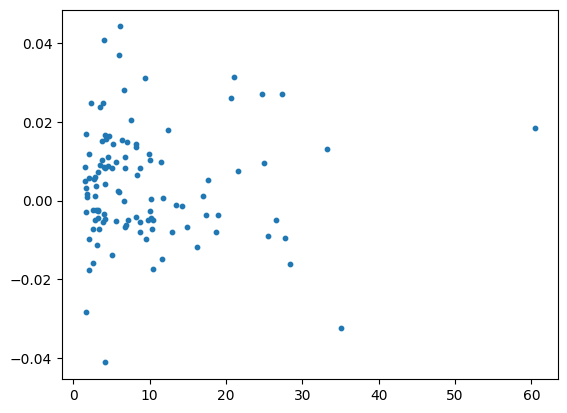

In [163]:
trades = processor.column_date_processing(trades[["date","abs","direction","std","ticker","GICS Sector","adjclose","return"]])

plt.scatter(trades["std"],trades["return"],s=10)
plt.show()


In [164]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio = processor.merge(portfolio,benchmark,on="date").dropna()
portfolio["bcr"] = (portfolio["sp500"] - portfolio["sp500"].iloc[0]) / portfolio["sp500"].iloc[0] + 1
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

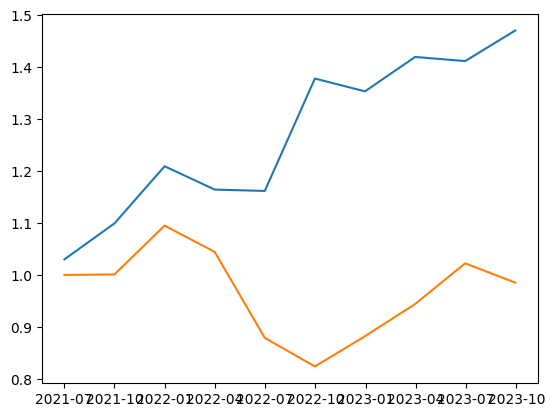

In [165]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [166]:
recommendations = trades.tail(positions)

In [167]:
recommendations

,date,abs,direction,std,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
99,2023-09-29 00:00:00+00:00,0.018571,1.0,25.466424,CHTR,Communication Services,439.820000,-0.009024,2023,3,9,39,4
100,2023-09-29 00:00:00+00:00,0.017535,1.0,6.331998,NKE,Consumer Discretionary,95.620000,0.015321,2023,3,9,39,4
101,2023-09-29 00:00:00+00:00,0.028866,1.0,3.257997,WMT,Consumer Staples,159.930000,-0.002651,2023,3,9,39,4
102,2023-09-29 00:00:00+00:00,0.009027,1.0,5.023669,CVX,Energy,166.842947,-0.013931,2023,3,9,39,4
103,2023-09-29 00:00:00+00:00,0.045560,1.0,1.533293,AIG,Financials,60.600000,0.008597,2023,3,9,39,4
104,2023-09-29 00:00:00+00:00,0.001749,1.0,17.030664,AMGN,Health Care,266.648619,0.001122,2023,3,9,39,4
105,2023-09-29 00:00:00+00:00,0.001355,-1.0,5.927281,FDX,Industrials,264.920000,0.002299,2023,3,9,39,4
106,2023-09-29 00:00:00+00:00,0.016015,1.0,21.634636,NVDA,Information Technology,434.990000,0.007520,2023,3,9,39,4
107,2023-09-29 00:00:00+00:00,0.021579,1.0,6.778800,LIN,Materials,372.350000,0.011124,2023,3,9,39,4
108,2023-09-29 00:00:00+00:00,0.070610,1.0,4.288664,SPG,Real Estate,108.030000,0.015607,2023,3,9,39,4


In [168]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()